In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('crop_data.csv')

In [3]:
df.head()

,ndvi_mean,ndvi_std,ndvi_min,ndvi_max,gndvi,savi,evi,red_edge_1,red_edge_2,nir_reflectance,soil_brightness,canopy_density,moisture_index,grid_x,grid_y,crop_health_label
0,0.462178,0.118574,0.345162,0.527650,0.434070,0.493184,0.426272,0.538210,0.387860,0.715725,0.531091,0.586647,0.679785,9,0,Healthy
1,0.865500,0.023196,0.814436,1.056953,0.855039,0.887622,0.807505,0.200828,0.391693,0.350926,0.304631,0.418664,0.926373,4,8,Healthy
2,0.712396,0.022876,0.539486,0.881657,0.628224,0.721757,0.708308,0.139121,0.474993,0.479509,0.394532,0.829622,0.443202,6,7,Healthy
3,0.619061,0.062069,0.515087,0.696248,0.578767,0.609120,0.640899,0.494059,0.354945,0.555526,0.594686,0.882743,0.788671,4,5,Healthy
4,0.309213,0.083524,0.178098,0.466014,0.357456,0.357234,0.434805,0.517743,0.152411,0.767144,0.781283,0.916408,0.637918,14,19,Healthy


### Explanation of the Dataset
#### This dataset represents crop health information collected from drone-based multispectral imagery.
#### Each row in the dataset represents a small grid area of a far field, and each column contains vegetation indices and environmental features that describe the condition of crops in that location.
#### These features help us understand plant health, moisture levels, canopy density, and vegetation condition.
#### Using this data, we can train a machine learning model to predict whther crops are healthy or stressed.

### How the Data Works
#### The Datset contains vegetaion indices such as:
#### NDVI
#### GNDVI
#### SAVI
#### EVI

#### These indices are calculated from different light wavelengths captured by a drone camera.
#### Plants reflect and absorb light differently depending on their health condition, so these indices help detect crop stress early

### Other Features in the Dataset
#### Red edge bands :-> detect early plant stress
#### NIR reflectance :-> indicates plant vitality
#### Soil brightness :-> shows soil exposure
#### Canopy density :-> measures plant coverage
#### Moisture index :-> indicates water availability
#### There also grid coordinates (grid_x, grid_y) that represent the spatial location of each ovservation in the field.

### Target Variable
#### The column crop_health_label indicates the crop condition:
#### Healthy
#### Stressed
#### This target variable used to train the machine learning model.

### Final Goal of the Dataset
#### The goal of this dataset is to build an AI model that can detect crop stress using drone imagery data. 
#### This helps farmers and agronomists:
#### Identify stressed areas in fields
#### Monitor crop health
#### Take early action to improve yield.

## Task:1 Dataunderstanding

In [4]:
print('Shape:', df.shape)
print('nColumns:', df.columns)
print('nMissing values:\n',df.isnull().sum())
print('nData types & non-null count:\n')
df.info()

Shape: (1200, 16)
nColumns: Index(['ndvi_mean', 'ndvi_std', 'ndvi_min', 'ndvi_max', 'gndvi', 'savi', 'evi',
       'red_edge_1', 'red_edge_2', 'nir_reflectance', 'soil_brightness',
       'canopy_density', 'moisture_index', 'grid_x', 'grid_y',
       'crop_health_label'],
      dtype='object')
nMissing values:
 ndvi_mean            0
ndvi_std             0
ndvi_min             0
ndvi_max             0
gndvi                0
savi                 0
evi                  0
red_edge_1           0
red_edge_2           0
nir_reflectance      0
soil_brightness      0
canopy_density       0
moisture_index       0
grid_x               0
grid_y               0
crop_health_label    0
dtype: int64
nData types & non-null count:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ndvi_mean          1200 non-null   float64
 1   ndvi_std           

In [5]:
df.describe()

,ndvi_mean,ndvi_std,ndvi_min,ndvi_max,gndvi,savi,evi,red_edge_1,red_edge_2,nir_reflectance,soil_brightness,canopy_density,moisture_index,grid_x,grid_y
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,0.549409,0.084760,0.426339,0.673198,0.549456,0.548230,0.547482,0.347123,0.353908,0.548972,0.445149,0.651057,0.548473,9.555833,9.512500
std,0.206205,0.037428,0.209405,0.210139,0.209522,0.210656,0.217635,0.143147,0.143760,0.204472,0.206082,0.204135,0.259727,5.793662,5.813749
min,0.203242,0.020203,0.021354,0.265189,0.085060,0.119313,0.068225,0.100120,0.101227,0.200110,0.100934,0.300388,0.100279,0.000000,0.000000
25%,0.366633,0.052097,0.247114,0.487883,0.366233,0.365079,0.369241,0.224678,0.232504,0.368337,0.264461,0.468347,0.327327,5.000000,4.000000
50%,0.556761,0.085807,0.435165,0.670934,0.550906,0.546413,0.553370,0.346752,0.353218,0.543587,0.438322,0.649936,0.545526,10.000000,10.000000
75%,0.729287,0.115859,0.602736,0.852604,0.719411,0.727774,0.733130,0.470124,0.479491,0.730997,0.623496,0.835916,0.775092,15.000000,15.000000
max,0.899802,0.149924,0.835727,1.087604,0.972632,0.974679,1.030173,0.599753,0.599837,0.899089,0.799191,0.999864,0.999932,19.000000,19.000000



Class distribution:

crop_health_label
Healthy     65.0
Stressed    35.0
Name: proportion, dtype: float64


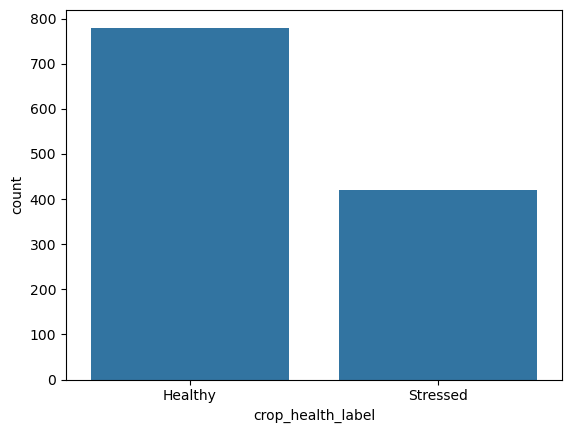

<Figure size 640x480 with 0 Axes>

In [6]:
# Target balance
print('\nClass distribution:\n')
print(df['crop_health_label'].value_counts(normalize=True)*100)

sns.countplot(x='crop_health_label', data=df)
plt.figure('Healthy vs Stressed Distribution')
plt.show()

In [7]:
df.columns

Index(['ndvi_mean', 'ndvi_std', 'ndvi_min', 'ndvi_max', 'gndvi', 'savi', 'evi',
       'red_edge_1', 'red_edge_2', 'nir_reflectance', 'soil_brightness',
       'canopy_density', 'moisture_index', 'grid_x', 'grid_y',
       'crop_health_label'],
      dtype='object')

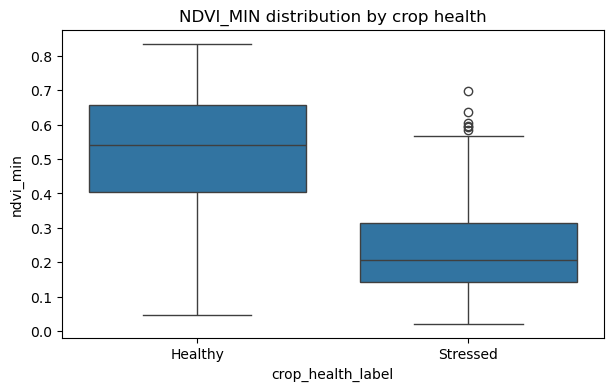

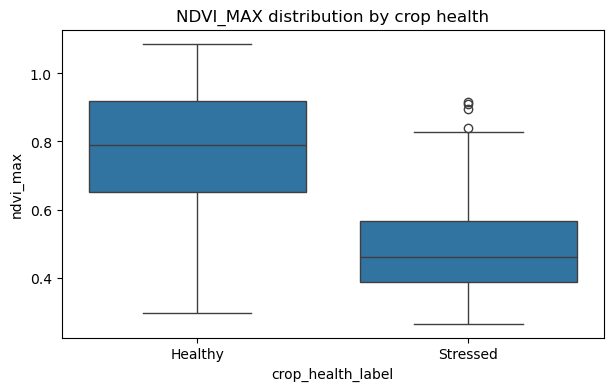

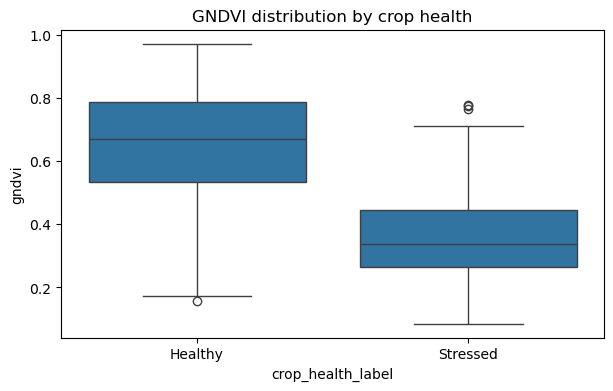

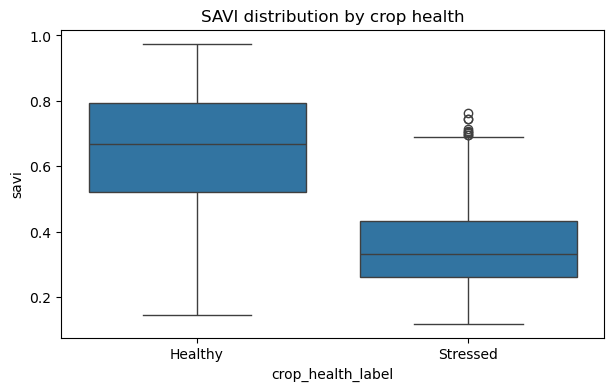

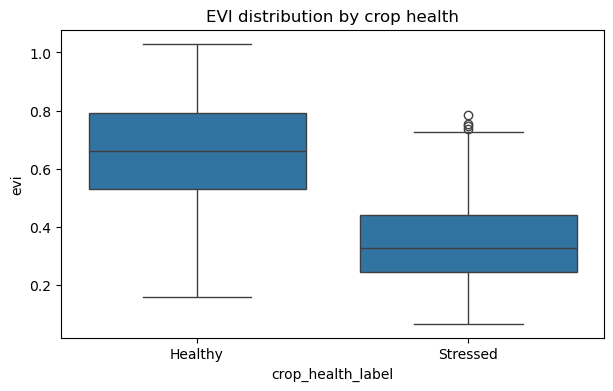

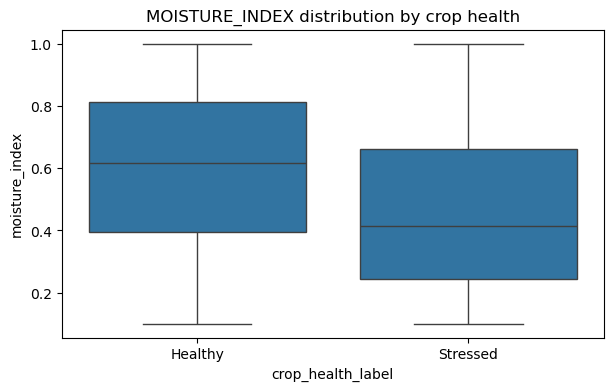

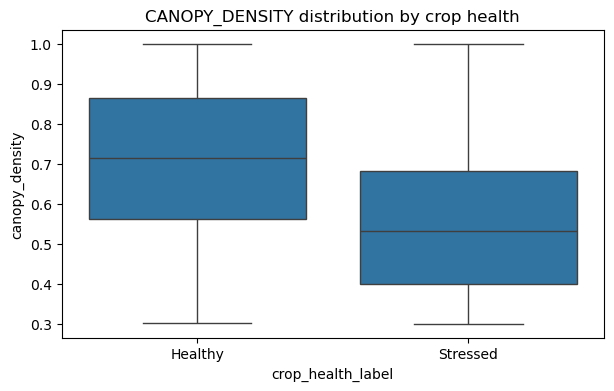

In [8]:
# key indices boxplot stressed vs heatly
important_indices = ['ndvi_min', 'ndvi_max','gndvi','savi','evi','moisture_index','canopy_density']
for i in important_indices:
    if i in df.columns:
        plt.figure(figsize=(7,4))
        sns.boxplot(x='crop_health_label',y=i, data=df)
        plt.title(f'{i.upper()} distribution by crop health')
        plt.show()

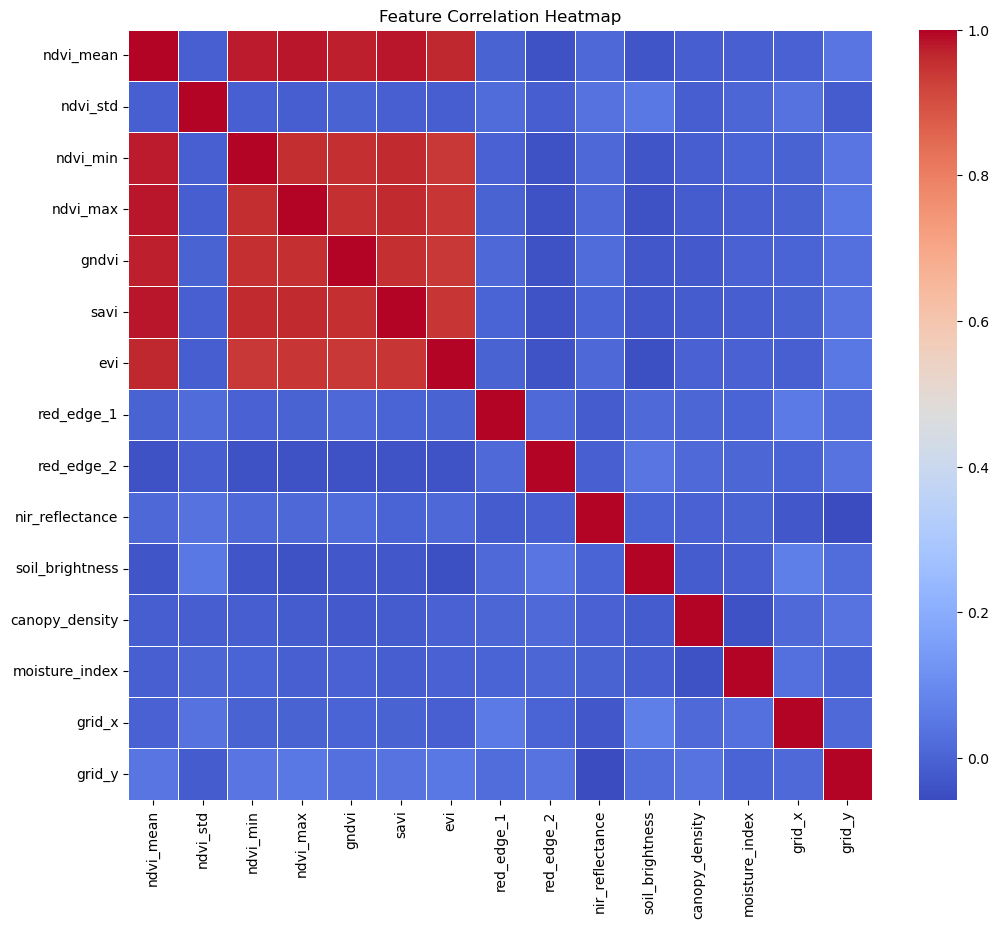

In [11]:
#correlation heatmap
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidth=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

In [14]:
X = df.drop(['crop_health_label','grid_x','grid_y'],axis=1)
y = df['crop_health_label'].map({'Healthy': 0, 'Stressed':1})
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

Random Forest:

Classification_report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       156
           1       0.94      0.89      0.91        84

    accuracy                           0.94       240
   macro avg       0.94      0.93      0.94       240
weighted avg       0.94      0.94      0.94       240

ROC-AUC: 0.9821047008547008


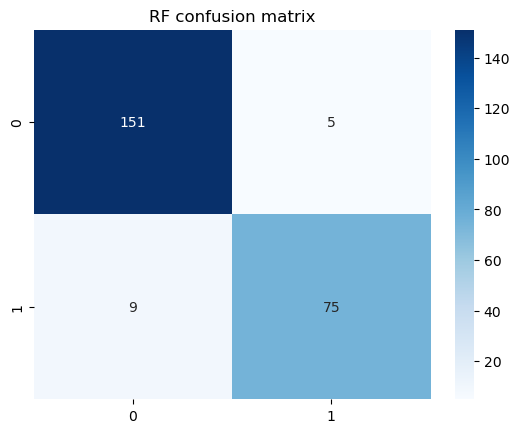

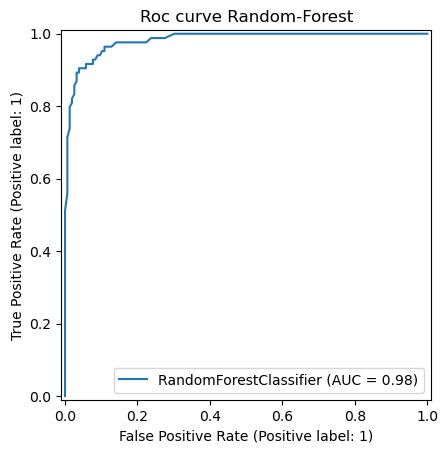

In [17]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print('Random Forest:')
print('\nClassification_report:\n', classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

#confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), cmap='Blues', fmt='d', annot=True)
plt.title('RF confusion matrix')
plt.show()

#Roc curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('Roc curve Random-Forest')
plt.show()

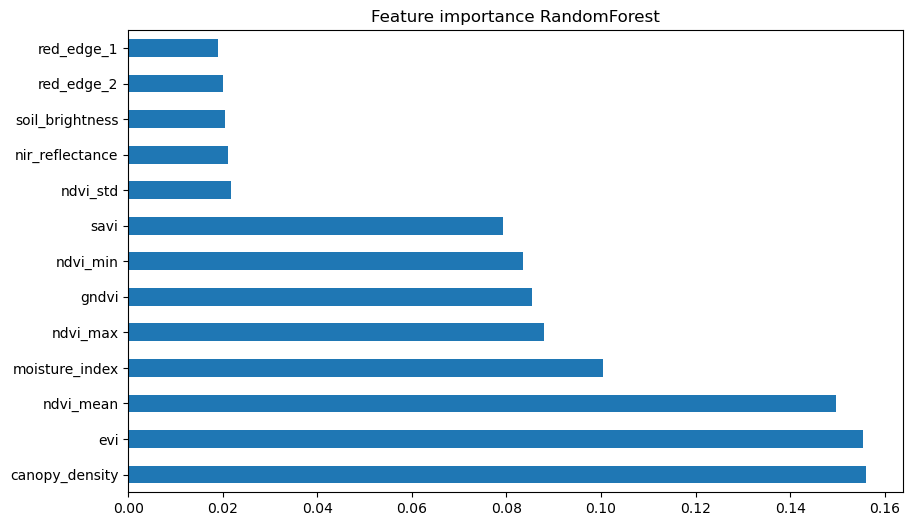

In [24]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='barh', figsize=(10,6))
plt.title('Feature importance RandomForest')
plt.show()

In [26]:
# Spatial Analysis and visualization
df['stress_prob'] = model.predict_proba(X)[:,1]
# grid-wise avg stress
grid_summary = df.groupby(['grid_x','grid_y'])['stress_prob'].agg(['mean','count']).reset_index()
grid_summary = grid_summary.rename(columns={'mean': 'avg_stress_prob'})

In [28]:
pivot_table = grid_summary.pivot(index='grid_y', columns='grid_x', values='avg_stress_prob')

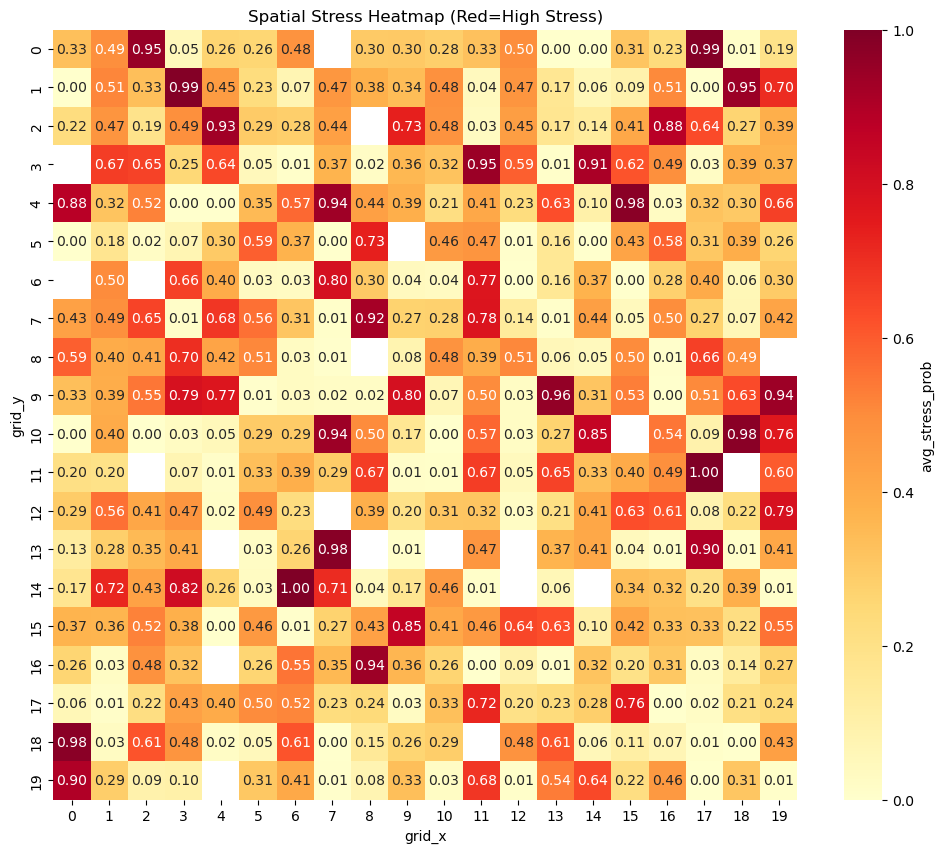

In [30]:
plt.figure(figsize=(12,10))
sns.heatmap(pivot_table, cmap='YlOrRd', annot=True, fmt='.2f', cbar_kws={'label': 'avg_stress_prob'})
plt.title('Spatial Stress Heatmap (Red=High Stress)')
plt.xlabel('grid_x')
plt.ylabel('grid_y')
plt.show()

## Drone Agronomy and Interpretaion

#### The spatial heatmap shows the distribution of predicted crop stress across different grid locations in the field. Areas with higher stress probability(red regions) indicate zones where crops are likely experiencing significant stress and require immediate drone inspection. Moderate stress areas should be monitored more frequently, while low stress area require routine monitoring. This approach enables targeted drone scouting and supports precision agriculture practices.

## Limitations and improvements
#### The current analysis has several limitations. The dataset relatively small and may not represent real agriculture field variability. It also captures crop conditions at a single time point, while crop stress changes over time. Additionally, Important real-world factors such as weather conditions, soil-nutrients, irrigation patterns, and pest activity are not included, which may limit model's ability to fully explain crop stress.

#### The system can be improved by integrating real-world data sources. Adding weather data such as rainfall, temperature and humidity would help capture environmental stress factors. Incorporating soil information like moisture, pH, and nutrient levels can further imporove predictions. Collecting time series drone imagery across multiple growth stages would allow the model to detect stress trends and enable more accurate and reliable crop health monitoring.